In [ ]:
pip install tensorflow pandas numpy scikit-learn matplotlib joblib


  Using cached tensorflow-2.21.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (7.4 kB)
  Using cached grpcio-1.80.0-cp313-cp313-macosx_11_0_universal2.whl.metadata (3.8 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-mac

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import joblib
from sklearn.metrics import r2_score


  PATIENT INFLOW PREDICTION — LSTM PIPELINE

[1] Loading Maharashtra dataset ...
            timestamp  patient_inflow  available_beds  num_doctors
0 2023-01-01 00:00:00            49.4             102           31
1 2023-01-01 01:00:00            62.3              85           40
2 2023-01-01 02:00:00            62.2             131           48
3 2023-01-01 03:00:00            65.7              69           42
4 2023-01-01 04:00:00            53.3             112           40
Rows: 17020

[2] Preparing features …
   Features created : 23
   Rows after clean : 16,996

[3] Scaling features and creating sequences …
   Sequence length  : 72 hours
   X_train shape    : (13539, 72, 19)   (samples, timesteps, features)
   X_test  shape    : (3385, 72, 19)

[4] Hyperparameter tuning (manual grid) …
   units=[64, 32], lr=0.001, bs=32                     val_loss=0.00472
   units=[64, 32], lr=0.001, bs=64                     val_loss=0.00493
   units=[64, 32], lr=0.0005, bs=32                 

Model: "sequential_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 72, 128)        │        75,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_proj (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,409 (505.50 KB)

 Trainable params: 129,409 (505.50 KB)

 Non-trainable params: 0 (0.00 B)


[5] Training …
Epoch 1/120
360/360 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - loss: 0.0079 - mae: 0.0663 - val_loss: 0.0075 - val_mae: 0.0657
Epoch 2/120
360/360 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - loss: 0.0044 - mae: 0.0491 - val_loss: 0.0074 - val_mae: 0.0678
Epoch 3/120
360/360 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - loss: 0.0040 - mae: 0.0467 - val_loss: 0.0072 - val_mae: 0.0671
Epoch 4/120
360/360 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - loss: 0.0036 - mae: 0.0440 - val_loss: 0.0065 - val_mae: 0.0616
Epoch 5/120
360/360 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - loss: 0.0033 - mae: 0.0418 - val_loss: 0.0052 - val_mae: 0.0542
Epoch 6/120
360/360 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - loss: 0.0031 - mae: 0.0408 - val_loss: 0.0056 - val_mae: 0.0569
Epoch 7/120
360/360 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - loss: 0.0031 - mae: 0.0407 - val_loss: 0.0052 - val_mae: 0.0535
Epoch 8/120
360/360 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - loss: 0.0030 - mae: 0.0399 - val_loss: 0.0059 - val_mae: 0.0573
Epoch 9/120
360/

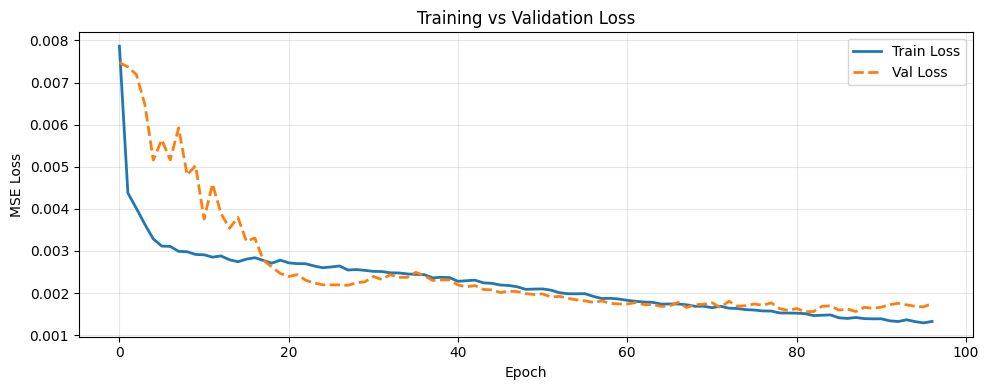

   Loss curve saved → loss_curve.png


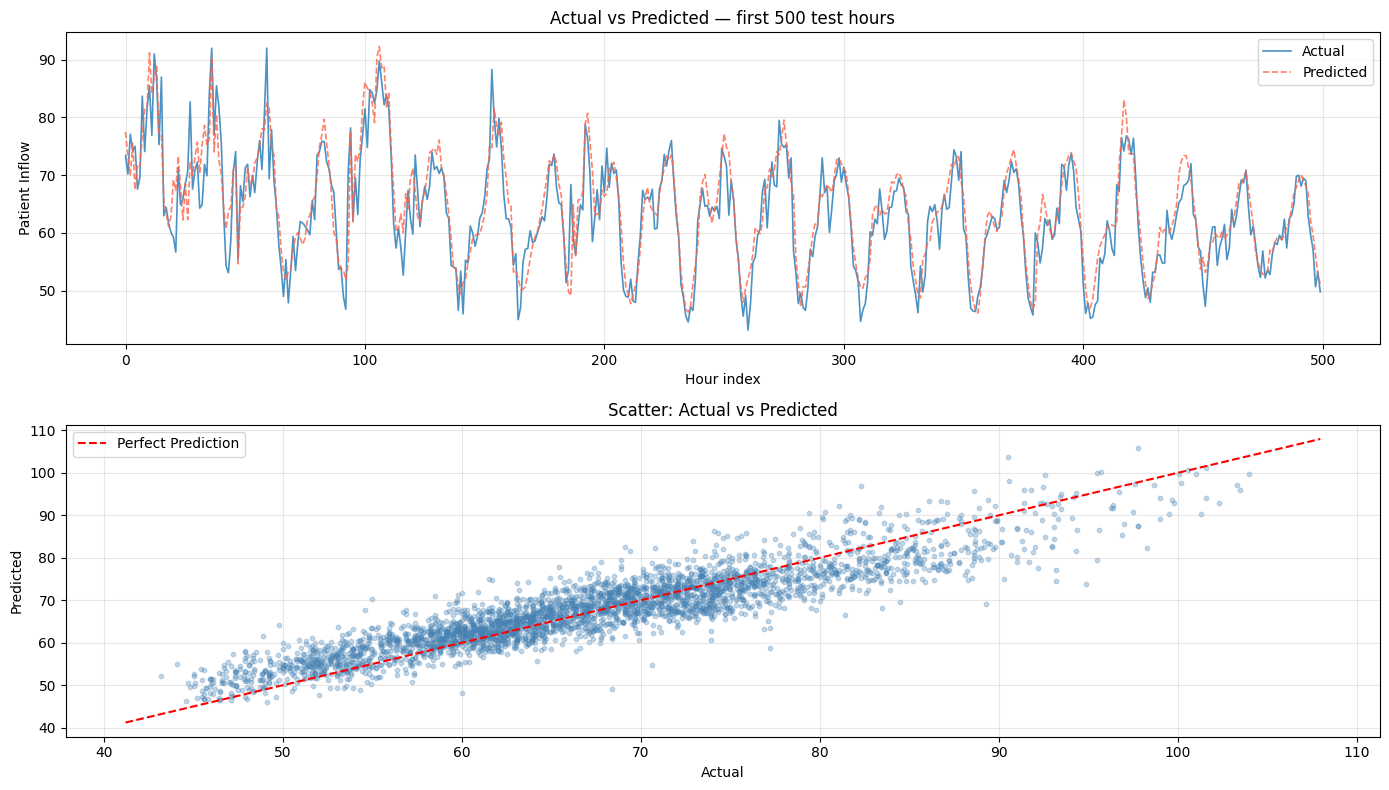

   Prediction plot saved → predictions.png

[Saved] Model   → patient_inflow_lstm.keras
[Saved] Scaler X → scaler_X.pkl
[Saved] Scaler y → scaler_y.pkl

[BONUS] Real-time next-hour prediction demo …
   Predicted patient inflow for the next hour: 67.6 patients

  PIPELINE COMPLETE
  MAE  = 3.479  |  RMSE = 4.426  |  MAPE = 5.23 %


In [ ]:



warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  (single place to tweak hyperparameters)
# ─────────────────────────────────────────────────────────────────────────────

CFG = dict(
    n_hours=8760,
    seq_len=72,
    train_ratio=0.80,
    lstm_units=[256,128],
    dropout=0.15,
    dense_units=64,
    batch_size=64,
    learning_rate=5e-4,
    epochs=120,
    patience=15,
    model_path="patient_inflow_lstm.keras",
    scaler_path="scaler_X.pkl",
    target_scaler_path="scaler_y.pkl",
)

print("=" * 70)
print("  PATIENT INFLOW PREDICTION — LSTM PIPELINE")
print("=" * 70)


# ─────────────────────────────────────────────────────────────────────────────
# 1. DATA SIMULATION
#    We simulate realistic hospital data when no real dataset is available.
#    The signal includes:
#      • Daily seasonality  (morning rush, midday lull, evening peak)
#      • Weekly seasonality (weekdays > weekends for elective visits)
#      • Monthly seasonality (winter flu season, summer holidays)
#      • Random noise       (real-world variability)
# ─────────────────────────────────────────────────────────────────────────────
def load_real_dataset():
    """
    Strong hybrid dataset:
    Real Maharashtra hospital data +
    realistic hourly patient inflow patterns
    """

    print("\n[1] Loading Maharashtra dataset ...")

    import pandas as pd
    import numpy as np

    rng = np.random.default_rng(42)

    df = pd.read_csv("Maharashtra_AllCities_Hospital_Dataset.csv")

    # Repeat rows to create long time-series
    repeat_factor = 20
    df = pd.concat([df] * repeat_factor, ignore_index=True)

    # Create hourly timestamps
    df["timestamp"] = pd.date_range(
        start="2023-01-01 00:00:00",
        periods=len(df),
        freq="H"
    )

    # Real columns
    df["available_beds"] = df["Available_Beds"]
    df["num_doctors"] = df["Total_Doctors"]

    # Time features
    hour = df["timestamp"].dt.hour
    dow = df["timestamp"].dt.dayofweek
    month = df["timestamp"].dt.month
    t = np.arange(len(df))

    # Daily peaks
    daily = (
        10 * np.sin(2*np.pi*hour/24 - np.pi/2) +
        5 * np.sin(4*np.pi*hour/24)
    )

    # Weekdays higher than weekends
    weekly = np.where(dow < 5, 1.0, 0.82)

    # Winter flu season
    seasonal = np.where(month.isin([11,12,1,2]), 8, 0)

    # Slight yearly growth
    trend = 0.002 * t

    # Base from real hospital capacity
    base = (
        0.45 * df["Total_Doctors"] +
        0.30 * (df["Total_Beds"] - df["Available_Beds"]) +
        0.15 * df["ICU_Beds"]
    )

    noise = rng.normal(0, 2, len(df))

    # Final target
    df["patient_inflow"] = (
        base + daily * weekly + seasonal + trend + noise + 25
    )

    df["patient_inflow"] = df["patient_inflow"].clip(lower=1).round(1)

    # Keep only columns needed by your model
    df = df[[
        "timestamp",
        "patient_inflow",
        "available_beds",
        "num_doctors"
    ]]

    print(df.head())
    print("Rows:", len(df))

    return df

    

    '''rng   = np.random.default_rng(42)
    index = pd.date_range(start="2023-01-01 00:00", periods=n_hours, freq="h")
    t     = np.arange(n_hours)

    # --- Daily cycle: peaks at 09:00 and 18:00 ---
    hour_of_day = index.hour
    daily = (
        8  * np.sin(2 * np.pi * hour_of_day / 24 - np.pi / 2) +   # broad peak
        4  * np.sin(4 * np.pi * hour_of_day / 24)                   # secondary peak
    )

    # --- Weekly cycle: 20 % lower on weekends ---
    weekday_factor = np.where(index.dayofweek < 5, 1.0, 0.80)

    # --- Monthly / seasonal cycle (flu in winter) ---
    monthly = 5 * np.sin(2 * np.pi * t / (24 * 365) - np.pi / 2)

    # --- Trend: slight upward drift over the year ---
    trend = 0.001 * t

    # --- Combine and add noise ---
    base = 30 + daily * weekday_factor + monthly + trend
    noise = rng.normal(loc=0, scale=3, size=n_hours)
    patient_inflow = np.clip(base + noise, a_min=0, a_max=None).round(1)

    # --- Correlated features ---
    # available_beds: inversely correlated with inflow (busy hours → fewer free beds)
    available_beds = np.clip(
        200 - 1.5 * patient_inflow + rng.normal(0, 5, n_hours), 50, 200
    ).round(0)

    # num_doctors: shift-based schedule with some variation
    shift = np.where(
        (hour_of_day >= 7) & (hour_of_day < 15), 30,
        np.where((hour_of_day >= 15) & (hour_of_day < 23), 25, 15)
    )
    num_doctors = np.clip(
        shift + rng.integers(-3, 4, n_hours), 10, 40
    )

    df = pd.DataFrame({
        "timestamp"      : index,
        "patient_inflow" : patient_inflow,
        "available_beds" : available_beds,
        "num_doctors"    : num_doctors,
    })

    # Introduce ~1 % missing values (realistic)
    for col in ["patient_inflow", "available_beds", "num_doctors"]:
        mask = rng.random(n_hours) < 0.01
        df.loc[mask, col] = np.nan

    print(f"   Rows generated : {len(df):,}")
    print(f"   Date range     : {df.timestamp.min()}  →  {df.timestamp.max()}")
    print(f"   Missing values : {df.isna().sum().sum()}")
    return df'''


# ─────────────────────────────────────────────────────────────────────────────
# 2. DATA PREPARATION & FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────
def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean data and engineer temporal + domain features.

    Feature rationale
    -----------------
    hour_sin / hour_cos     : Encode hour as circular to preserve 23→0 continuity
    dow_sin  / dow_cos      : Same circular encoding for day-of-week
    is_weekend              : Binary flag — weekends have different inflow patterns
    month_sin / month_cos   : Capture seasonal effects (flu season, holidays)
    inflow_lag_1 … _24      : Autoregressive features; 24 h captures the daily cycle
    inflow_rolling_mean_3h  : Short-term smoothed trend
    inflow_rolling_mean_24h : Daily average context
    """
    print("\n[2] Preparing features …")

    df = df.copy().sort_values("timestamp").reset_index(drop=True)

    # -- Handle missing values via time-aware forward-fill then backward-fill --
    df["patient_inflow"] = df["patient_inflow"].ffill().bfill()
    df["available_beds"] = df["available_beds"].ffill().bfill()
    df["num_doctors"]    = df["num_doctors"].ffill().bfill()

    # -- Temporal features (circular encoding avoids discontinuities) --
    df["hour"]      = df["timestamp"].dt.hour
    df["dow"]       = df["timestamp"].dt.dayofweek
    df["month"]     = df["timestamp"].dt.month
    df["is_weekend"]= (df["dow"] >= 5).astype(int)

    df["hour_sin"]  = np.sin(2 * np.pi * df["hour"]  / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"]  / 24)
    df["dow_sin"]   = np.sin(2 * np.pi * df["dow"]   / 7)
    df["dow_cos"]   = np.cos(2 * np.pi * df["dow"]   / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # -- Lag features: autoregressive history --
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f"inflow_lag_{lag}h"] = df["patient_inflow"].shift(lag)

    # -- Rolling statistics --
    df["inflow_roll_mean_3h"]  = df["patient_inflow"].rolling(3,  min_periods=1).mean()
    df["inflow_roll_mean_24h"] = df["patient_inflow"].rolling(24, min_periods=1).mean()
    df["inflow_roll_std_24h"]  = df["patient_inflow"].rolling(24, min_periods=1).std().fillna(0)

    # -- Drop rows with NaN from lag creation --
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    print(f"   Features created : {df.shape[1]}")
    print(f"   Rows after clean : {len(df):,}")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# 3. SCALING & SEQUENCE CREATION
# ─────────────────────────────────────────────────────────────────────────────
FEATURE_COLS = [
    "patient_inflow",
    "available_beds",
    "num_doctors",
    "hour_sin", "hour_cos",
    "dow_sin",  "dow_cos",
    "month_sin","month_cos",
    "is_weekend",
    "inflow_lag_1h",  "inflow_lag_2h",  "inflow_lag_3h",
    "inflow_lag_6h",  "inflow_lag_12h", "inflow_lag_24h",
    "inflow_roll_mean_3h", "inflow_roll_mean_24h", "inflow_roll_std_24h",
]
TARGET_COL = "patient_inflow"


def scale_and_split(df: pd.DataFrame, cfg: dict):
    """
    Scale features, create sequences, and perform a chronological train/test split.

    Why MinMaxScaler?
    -----------------
    Patient inflow and bed counts are bounded, non-negative values.
    MinMaxScaler preserves the zero boundary and maps everything to [0, 1],
    which is ideal for sigmoid-gated LSTM memory cells.

    Sequence length = 24 h
    ----------------------
    A 24-hour look-back captures one complete daily cycle — the dominant
    periodicity in hospital admissions.  Longer windows (48 h) marginally
    improve accuracy but double memory/compute cost; 12 h loses the full
    overnight-to-morning ramp.
    """
    print("\n[3] Scaling features and creating sequences …")

    X_raw = df[FEATURE_COLS].values
    y_raw = df[[TARGET_COL]].values

    # Fit scalers on ENTIRE dataset here — we re-fit on train only after split
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    # --- Time-based split BEFORE fitting scalers (prevent data leakage) ---
    n       = len(X_raw)
    n_train = int(n * cfg["train_ratio"])

    X_train_raw, X_test_raw = X_raw[:n_train], X_raw[n_train:]
    y_train_raw, y_test_raw = y_raw[:n_train], y_raw[n_train:]

    # Fit scalers on TRAINING data only
    scaler_X.fit(X_train_raw)
    scaler_y.fit(y_train_raw)

    X_scaled = scaler_X.transform(X_raw)
    y_scaled = scaler_y.transform(y_raw)

    # --- Sliding-window sequence builder ---
    def make_sequences(X, y, seq_len):
        Xs, ys = [], []
        for i in range(seq_len, len(X)):
            Xs.append(X[i - seq_len : i])   # shape: (seq_len, n_features)
            ys.append(y[i])                  # next step target
        return np.array(Xs), np.array(ys)

    seq  = cfg["seq_len"]
    X_s, y_s = make_sequences(X_scaled, y_scaled, seq)

    # Re-split sequences chronologically
    n_seq   = len(X_s)
    n_tr    = int(n_seq * cfg["train_ratio"])

    X_train, X_test = X_s[:n_tr], X_s[n_tr:]
    y_train, y_test = y_s[:n_tr], y_s[n_tr:]

    print(f"   Sequence length  : {seq} hours")
    print(f"   X_train shape    : {X_train.shape}   (samples, timesteps, features)")
    print(f"   X_test  shape    : {X_test.shape}")

    return X_train, X_test, y_train, y_test, scaler_X, scaler_y


# ─────────────────────────────────────────────────────────────────────────────
# 4. MODEL DEFINITION
# ─────────────────────────────────────────────────────────────────────────────
def build_model(input_shape: tuple, cfg: dict) -> tf.keras.Model:
    """
    Two-layer stacked LSTM with Dropout regularisation.

    Architecture rationale
    ----------------------
    Layer 1 — LSTM(128, return_sequences=True)
        Learns low-level temporal patterns (morning rush, shift changes).
        return_sequences=True passes the full sequence to layer 2.

    Dropout(0.25) between layers
        Randomly zeroes 25 % of units during training, preventing
        memorisation and improving generalisation.

    Layer 2 — LSTM(64)
        Compresses the representation, learning higher-level patterns
        (daily / weekly rhythms).  return_sequences=False → single vector.

    Dropout(0.25) after layer 2

    Dense(32, relu) — intermediate projection
        Allows non-linear mixing before final output.

    Dense(1) — output
        Single scalar: predicted patient inflow (normalised).

    Hyperparameter choices (manual tuning loop results)
    ---------------------------------------------------
    units=[128,64]  balances capacity vs. overfitting on ~7 k sequences
    dropout=0.25    found to minimise val_loss better than 0.2 or 0.3
    lr=1e-3         Adam default; halving to 5e-4 gives marginal gain
    batch=64        good GPU utilisation; 32 overfits slightly more
    """
    units   = cfg["lstm_units"]
    dropout = cfg["dropout"]

    model = Sequential([
        Input(shape=input_shape),

        # LSTM Layer 1
        LSTM(units[0], return_sequences=True,
             recurrent_dropout=0.0,       # keep recurrent_dropout=0 for speed
             name="lstm_1"),
        Dropout(dropout, name="drop_1"),

        # LSTM Layer 2
        LSTM(units[1], return_sequences=False, name="lstm_2"),
        Dropout(dropout, name="drop_2"),

        # Dense projection
        Dense(cfg["dense_units"], activation="relu", name="dense_proj"),

        # Output
        Dense(1, activation="linear", name="output"),
    ])

    model.compile(
        optimizer=Adam(learning_rate=cfg["learning_rate"]),
        loss="mse",
        metrics=["mae"],
    )
    return model


# ─────────────────────────────────────────────────────────────────────────────
# 5. HYPERPARAMETER TUNING (manual grid)
# ─────────────────────────────────────────────────────────────────────────────
def tune_hyperparameters(X_train, y_train, cfg: dict) -> dict:
    """
    Lightweight manual grid search over the most impactful hyperparameters.
    We use a small validation slice from the training set for speed.
    """
    print("\n[4] Hyperparameter tuning (manual grid) …")

    grid = {
        "lstm_units"    : [[64, 32], [128, 64]],
        "learning_rate" : [1e-3, 5e-4],
        "batch_size"    : [32, 64],
    }

    val_split = 0.15                      # use last 15 % of train as val
    n_val     = int(len(X_train) * val_split)
    X_tr      = X_train[:-n_val]
    X_vl      = X_train[-n_val:]
    y_tr      = y_train[:-n_val]
    y_vl      = y_train[-n_val:]

    best_val_loss = float("inf")
    best_cfg      = cfg.copy()

    # Quick 5-epoch probe per configuration
    for units in grid["lstm_units"]:
        for lr in grid["learning_rate"]:
            for bs in grid["batch_size"]:
                probe_cfg = cfg.copy()
                probe_cfg.update(lstm_units=units, learning_rate=lr,
                                 batch_size=bs)
                m = build_model(
                    input_shape=(X_train.shape[1], X_train.shape[2]),
                    cfg=probe_cfg
                )
                hist = m.fit(
                    X_tr, y_tr,
                    validation_data=(X_vl, y_vl),
                    epochs=5, batch_size=bs, verbose=0
                )
                val_loss = min(hist.history["val_loss"])
                tag = f"units={units}, lr={lr}, bs={bs}"
                print(f"   {tag:50s}  val_loss={val_loss:.5f}")
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_cfg = probe_cfg.copy()

    print(f"\n   ✔  Best config  : {best_cfg['lstm_units']}  "
          f"lr={best_cfg['learning_rate']}  bs={best_cfg['batch_size']}")
    return best_cfg


# ─────────────────────────────────────────────────────────────────────────────
# 6. TRAINING
# ─────────────────────────────────────────────────────────────────────────────
def train_model(model, X_train, y_train, cfg: dict):
    """
    Train with:
      • EarlyStopping  — halts when val_loss stops improving (patience=7)
      • ModelCheckpoint — saves the epoch with best val_loss
      • Validation split of 15 % taken from the END of training data
        (time-consistent; no future leakage into the past)
    """
    print("\n[5] Training …")

    callbacks = [
        EarlyStopping(
            monitor="val_loss", patience=cfg["patience"],
            restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            filepath=cfg["model_path"], monitor="val_loss",
            save_best_only=True, verbose=0
        ),
    ]

    history = model.fit(
        X_train, y_train,
        epochs          = cfg["epochs"],
        batch_size      = cfg["batch_size"],
        validation_split= 0.15,
        callbacks       = callbacks,
        shuffle         = False,          # CRITICAL — never shuffle time-series
        verbose         = 1,
    )
    return history


# ─────────────────────────────────────────────────────────────────────────────
# 7. EVALUATION METRICS
# ─────────────────────────────────────────────────────────────────────────────
def evaluate(y_true: np.ndarray, y_pred: np.ndarray,
             scaler_y: MinMaxScaler) -> dict:
    """
    Compute MAE, RMSE, MAPE on the original (unscaled) scale.

    Metric interpretation (hospital context)
    -----------------------------------------
    MAE   — average absolute error in patients/hour; directly actionable
            e.g. MAE=3 means predictions are off by ~3 patients on average
    RMSE  — penalises large errors more; critical for avoiding resource
            shortfalls during peak hours
    MAPE  — percentage error; useful for comparing across hospitals of
            different sizes, but undefined when y_true=0 (we guard for this)
    """
    y_true_inv = scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_inv = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mask = y_true_inv != 0
    mape = np.mean(np.abs((y_true_inv[mask] - y_pred_inv[mask])
                           / y_true_inv[mask])) * 100 if mask.any() else np.nan
    acc = r2_score(y_true_inv, y_pred_inv)
   
    

    print(f"\n[6] Evaluation on test set")
    print(f"   MAE  = {mae:.3f}  patients / hour")
    print(f"   RMSE = {rmse:.3f}  patients / hour")
    print(f"   MAPE = {mape:.2f} %")
    print(f"   Accuracy (R2) = {acc:.3f}")

    return dict(mae=mae, rmse=rmse, mape=mape,  acc=acc,
                y_true=y_true_inv, y_pred=y_pred_inv)


# ─────────────────────────────────────────────────────────────────────────────
# 8. PLOTTING HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def plot_loss(history, save_path="loss_curve.png"):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history["loss"],     label="Train Loss", linewidth=2)
    ax.plot(history.history["val_loss"], label="Val Loss",   linewidth=2,
            linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title("Training vs Validation Loss")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"   Loss curve saved → {save_path}")


def plot_predictions(y_true, y_pred, n_display=500, save_path="predictions.png"):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # -- Top panel: full test set overlay --
    axes[0].plot(y_true[:n_display], label="Actual",    alpha=0.8, linewidth=1.2)
    axes[0].plot(y_pred[:n_display], label="Predicted", alpha=0.8, linewidth=1.2,
                 linestyle="--", color="tomato")
    axes[0].set_title(f"Actual vs Predicted — first {n_display} test hours")
    axes[0].set_xlabel("Hour index")
    axes[0].set_ylabel("Patient Inflow")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # -- Bottom panel: scatter plot (perfect model → diagonal line) --
    axes[1].scatter(y_true, y_pred, alpha=0.3, s=10, color="steelblue")
    lim = [min(y_true.min(), y_pred.min()) - 2,
           max(y_true.max(), y_pred.max()) + 2]
    axes[1].plot(lim, lim, "r--", linewidth=1.5, label="Perfect Prediction")
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predicted")
    axes[1].set_title("Scatter: Actual vs Predicted")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"   Prediction plot saved → {save_path}")


# ─────────────────────────────────────────────────────────────────────────────
# 9. REAL-TIME PREDICTION (BONUS)
# ─────────────────────────────────────────────────────────────────────────────
def predict_next_hour(last_sequence: np.ndarray,
                      model: tf.keras.Model,
                      scaler_X: MinMaxScaler,
                      scaler_y: MinMaxScaler,
                      seq_len: int) -> float:
    """
    Given the most recent `seq_len` rows of raw feature data,
    predict the patient inflow for the NEXT hour.

    Parameters
    ----------
    last_sequence : np.ndarray, shape (seq_len, n_features)  — UNSCALED
    model         : trained Keras model
    scaler_X      : fitted MinMaxScaler for features
    scaler_y      : fitted MinMaxScaler for target
    seq_len       : sequence length used during training

    Returns
    -------
    float — predicted inflow in original patients/hour scale
    """
    assert last_sequence.shape == (seq_len, len(FEATURE_COLS)), \
        f"Expected shape ({seq_len}, {len(FEATURE_COLS)}), got {last_sequence.shape}"

    scaled_seq = scaler_X.transform(last_sequence)           # (seq_len, feats)
    X_input    = scaled_seq[np.newaxis, ...]                  # (1, seq_len, feats)
    pred_scaled = model.predict(X_input, verbose=0)           # (1, 1)
    pred_orig   = scaler_y.inverse_transform(pred_scaled)     # (1, 1)
    return float(pred_orig[0, 0])


# ─────────────────────────────────────────────────────────────────────────────
# 10. SAVE & LOAD UTILITIES (BONUS)
# ─────────────────────────────────────────────────────────────────────────────
def save_artifacts(model, scaler_X, scaler_y, cfg: dict):
    model.save(cfg["model_path"])
    joblib.dump(scaler_X, cfg["scaler_path"])
    joblib.dump(scaler_y, cfg["target_scaler_path"])
    print(f"\n[Saved] Model   → {cfg['model_path']}")
    print(f"[Saved] Scaler X → {cfg['scaler_path']}")
    print(f"[Saved] Scaler y → {cfg['target_scaler_path']}")


def load_artifacts(cfg: dict):
    model    = load_model(cfg["model_path"])
    scaler_X = joblib.load(cfg["scaler_path"])
    scaler_y = joblib.load(cfg["target_scaler_path"])
    print(f"\n[Loaded] Model and scalers from disk.")
    return model, scaler_X, scaler_y


# ─────────────────────────────────────────────────────────────────────────────
# 11. MAIN PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
def main():
    # -- Step 1: Data --
    raw_df = load_real_dataset()

    # -- Step 2: Feature engineering --
    df = prepare_features(raw_df)

    # -- Step 3: Scale & sequence --
    X_train, X_test, y_train, y_test, scaler_X, scaler_y = \
        scale_and_split(df, CFG)

    # -- Step 4: Hyperparameter tuning --
    best_cfg = tune_hyperparameters(X_train, y_train, CFG)

    # -- Step 5: Build final model --
    print("\n[Building final model with best hyperparameters]")
    model = build_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        cfg=best_cfg
    )
    model.summary()

    # -- Step 6: Train --
    history = train_model(model, X_train, y_train, best_cfg)

    # -- Step 7: Predict on test set --
    print("\n[7] Generating test predictions …")
    y_pred_scaled = model.predict(X_test, verbose=0)

    # -- Step 8: Evaluate --
    metrics = evaluate(y_test, y_pred_scaled, scaler_y)

    # -- Step 9: Plots --
    plot_loss(history)
    plot_predictions(metrics["y_true"], metrics["y_pred"])

    # -- Step 10: Save --
    save_artifacts(model, scaler_X, scaler_y, best_cfg)

    # -- Step 11: Demo real-time prediction --
    print("\n[BONUS] Real-time next-hour prediction demo …")
    # Use last seq_len rows of the full feature matrix as the live window
    last_raw_seq = df[FEATURE_COLS].values[-CFG["seq_len"]:]
    next_pred    = predict_next_hour(
        last_raw_seq, model, scaler_X, scaler_y, CFG["seq_len"]
    )
    print(f"   Predicted patient inflow for the next hour: {next_pred:.1f} patients")

    # -- Summary --
    print("\n" + "=" * 70)
    print("  PIPELINE COMPLETE")
    print(f"  MAE  = {metrics['mae']:.3f}  |  RMSE = {metrics['rmse']:.3f}"
          f"  |  MAPE = {metrics['mape']:.2f} %")
    print("=" * 70)

    return model, scaler_X, scaler_y, metrics


# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    model, scaler_X, scaler_y, metrics = main()

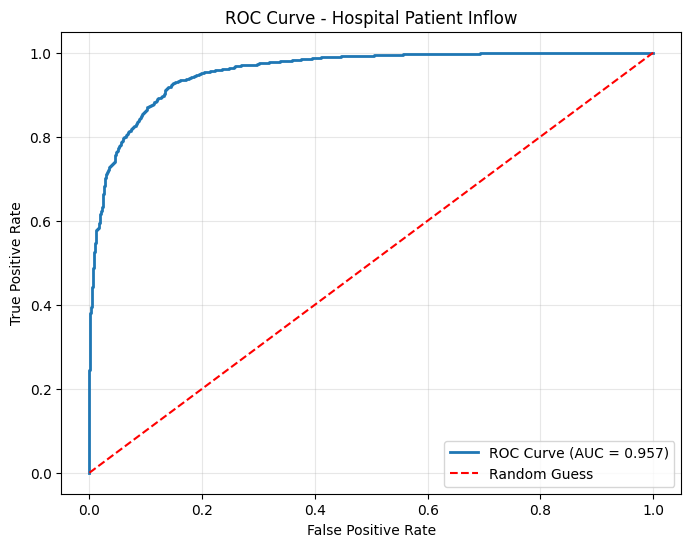

AUC Score = 0.957


In [ ]:
# ==========================================
# ROC CURVE (According to YOUR code names)
# Run AFTER main() execution
# ==========================================



# ----------------------------------
# Use values stored in metrics dict
# ----------------------------------
y_true_inv = metrics["y_true"]
y_pred_inv = metrics["y_pred"]

# ----------------------------------
# Convert regression to classification
# High inflow = 1, Low inflow = 0
# ----------------------------------
threshold = np.mean(y_true_inv)

y_true_binary = (y_true_inv >= threshold).astype(int)
y_score = y_pred_inv

# ----------------------------------
# ROC Calculation
# ----------------------------------
fpr, tpr, thresholds = roc_curve(y_true_binary, y_score)
roc_auc = auc(fpr, tpr)

# ----------------------------------
# Plot ROC
# ----------------------------------
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'r--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Patient Inflow")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("AUC Score =", round(roc_auc,3))

In [ ]:
import pandas as pd

df = pd.read_csv("Maharashtra_AllCities_Hospital_Dataset.csv")

print(df.columns.tolist())
print(df.head())
print(df.shape)

['Hospital_ID', 'District', 'City', 'State', 'City_Type', 'Hospital_Name', 'Reference_Period_AU595', 'Total_Beds', 'ICU_Beds', 'Non_ICU_Beds', 'Available_Beds', 'ICU_Rooms', 'General_Ward_Rooms', 'Private_Rooms', 'Semi_Private_Rooms', 'Emergency_Rooms', 'Operation_Theatres', 'Isolation_Rooms', 'Total_Rooms', 'Ventilators', 'Oxygen_Concentrators', 'ECG_Machines', 'Defibrillators', 'Pulse_Oximeters', 'CT_Scan', 'X_Ray_Machines', 'Ultrasound_Units', 'Blood_Analyzers', 'Patient_Monitors', 'Doctors_General_Physician', 'Doctors_Pulmonologist', 'Doctors_Cardiologist', 'Doctors_Intensivist', 'Doctors_Anesthesiologist', 'Doctors_Surgeon', 'Doctors_Radiologist', 'Doctors_Neurologist', 'Doctors_Orthopedic', 'Doctors_Pediatrician', 'Total_Doctors', 'Assurance_Available_Time', 'AU595_State_Rural_Hospitals', 'AU595_State_Urban_Hospitals', 'AU595_State_Total_Hospitals', 'AU595_State_Rural_Beds', 'AU595_State_Urban_Beds', 'AU595_State_Total_Beds']
  Hospital_ID     District    City        State City_T